# Correlation, Activity, and Space Analysis

This notebook analyzes the relationship between:
1. neuron-neuron correlation
2. neuron activity strength
3. neuron spatial position

## Analysis plan
- Load and preprocess data (RR-selected spike segments).
- Build class-wise correlation matrices.
- Quantify pairwise correlation vs spatial distance.
- Quantify pairwise correlation vs activity difference.
- Visualize spatial activity map and class-level summaries.
- Export key pairwise tables and summary statistics.


In [11]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from brainnetwork import load_data, preprocess_spike_data, compute_correlation_matrix

sns.set_theme(style="whitegrid", context="talk")
np.random.seed(42)


In [12]:
# -----------------------------
# User config
# -----------------------------
data_path = r"YOUR_DATA_PATH"
base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
idx = 5 # Change this index to select different datasets
data_path = base_dir + data_paths[idx] # 'M77_1031'
save_dir = Path("../results/custom_correlation_activity_space")
save_dir.mkdir(parents=True, exist_ok=True)

if data_path == "YOUR_DATA_PATH":
    raise ValueError("Please set `data_path` to one mouse raw data directory before running.")


In [13]:
# -----------------------------
# Load and preprocess
# -----------------------------
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path, data_type="spikes")
segments, labels, neuron_pos_rr = preprocess_spike_data(
    neuron_data, neuron_pos, start_edges, stimulus_data, extract_rr=True
)

print("segments shape:", segments.shape)   # (trials, neurons, timepoints)
print("labels shape:", labels.shape)
print("rr neuron_pos shape:", neuron_pos_rr.shape)
print("classes:", np.unique(labels))


原始神经数据形状: (8401, 35499)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 404 个 RR 神经元
  - 类别 2 贡献了 361 个 RR 神经元
  - 类别 3 贡献了 412 个 RR 神经元
三类并集后共筛选出 726 个唯一 RR 神经元
segments shape: (180, 726, 50)
labels shape: (180,)
rr neuron_pos shape: (2, 726)
classes: [1 2 3]


In [14]:
# -----------------------------
# Helper functions
# -----------------------------
def upper_triangle_values(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return matrix[mask], mask


def pairwise_distance_matrix(neuron_pos_xy):
    coords = neuron_pos_xy.T  # (n_neurons, 2)
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt(np.sum(diff ** 2, axis=2))


def compute_activity_vector(segments_cls, t_stimulus=10, l_stimulus=20):
    baseline_pre = segments_cls[:, :, :t_stimulus]
    baseline_post = segments_cls[:, :, t_stimulus + l_stimulus :]
    stim = segments_cls[:, :, t_stimulus : t_stimulus + l_stimulus]

    baseline = 0.5 * (baseline_pre.mean(axis=(0, 2)) + baseline_post.mean(axis=(0, 2)))
    stim_mean = stim.mean(axis=(0, 2))
    response_amp = stim_mean - baseline
    return response_amp


def build_pairwise_dataframe(corr_matrix, dist_matrix, activity_vector, class_id):
    corr_vals, mask = upper_triangle_values(corr_matrix)
    dist_vals = dist_matrix[mask]

    n = activity_vector.shape[0]
    act_diff = np.abs(activity_vector[:, None] - activity_vector[None, :])
    act_mean = 0.5 * (activity_vector[:, None] + activity_vector[None, :])

    return pd.DataFrame({
        "class_id": class_id,
        "corr": corr_vals,
        "abs_corr": np.abs(corr_vals),
        "distance": dist_vals,
        "activity_diff": act_diff[mask],
        "activity_mean": act_mean[mask],
        "n_neurons": n,
    })


def add_distance_bin_summary(df, value_col, n_bins=12):
    out = df.copy()
    out["distance_bin"] = pd.qcut(out["distance"], q=n_bins, duplicates="drop")
    summary = out.groupby("distance_bin", observed=False).agg(
        distance_mid=("distance", "median"),
        value_mean=(value_col, "mean"),
        value_sem=(value_col, lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=(value_col, "size"),
    ).reset_index(drop=True)
    return summary


def summarize_association(df, x_col, y_col):
    rho, p = stats.spearmanr(df[x_col], df[y_col])
    slope, intercept, r, p_lin, stderr = stats.linregress(df[x_col], df[y_col])
    return {
        "spearman_rho": rho,
        "spearman_p": p,
        "linear_r": r,
        "linear_p": p_lin,
        "linear_slope": slope,
        "linear_intercept": intercept,
        "linear_stderr": stderr,
    }


In [15]:
# -----------------------------
# Core analysis
# -----------------------------
dist_matrix = pairwise_distance_matrix(neuron_pos_rr)
class_ids = sorted(np.unique(labels).tolist())

pair_tables = []
association_rows = []

for cls in class_ids:
    cls_mask = labels == cls
    segments_cls = segments[cls_mask]

    corr_cls = compute_correlation_matrix(
        segments,
        labels=labels,
        class_filter=cls,
        zscore=True,
        balance=True,
        random_state=42,
    )
    activity_cls = compute_activity_vector(segments_cls)

    pair_df = build_pairwise_dataframe(
        corr_matrix=corr_cls,
        dist_matrix=dist_matrix,
        activity_vector=activity_cls,
        class_id=cls,
    )
    pair_tables.append(pair_df)

    assoc_dist = summarize_association(pair_df, "distance", "abs_corr")
    assoc_act = summarize_association(pair_df, "activity_diff", "abs_corr")

    association_rows.append({
        "class_id": cls,
        "relation": "abs_corr_vs_distance",
        **assoc_dist,
    })
    association_rows.append({
        "class_id": cls,
        "relation": "abs_corr_vs_activity_diff",
        **assoc_act,
    })

pairs_all = pd.concat(pair_tables, ignore_index=True)
association_df = pd.DataFrame(association_rows)
association_df


,class_id,relation,spearman_rho,spearman_p,linear_r,linear_p,linear_slope,linear_intercept,linear_stderr
0,1,abs_corr_vs_distance,-0.214225,0.0,-0.245249,0.000000e+00,-0.000083,0.226257,6.363489e-07
1,1,abs_corr_vs_activity_diff,-0.147566,0.0,-0.156985,0.000000e+00,-0.399946,0.200063,4.904622e-03
2,2,abs_corr_vs_distance,-0.220862,0.0,-0.245927,0.000000e+00,-0.000085,0.228720,6.549680e-07
3,2,abs_corr_vs_activity_diff,-0.111003,0.0,-0.104658,0.000000e+00,-0.246969,0.196844,4.574644e-03
4,3,abs_corr_vs_distance,-0.136526,0.0,-0.161859,0.000000e+00,-0.000056,0.222202,6.643130e-07
5,3,abs_corr_vs_activity_diff,-0.074013,0.0,-0.066258,8.591830e-254,-0.154824,0.200724,4.544902e-03


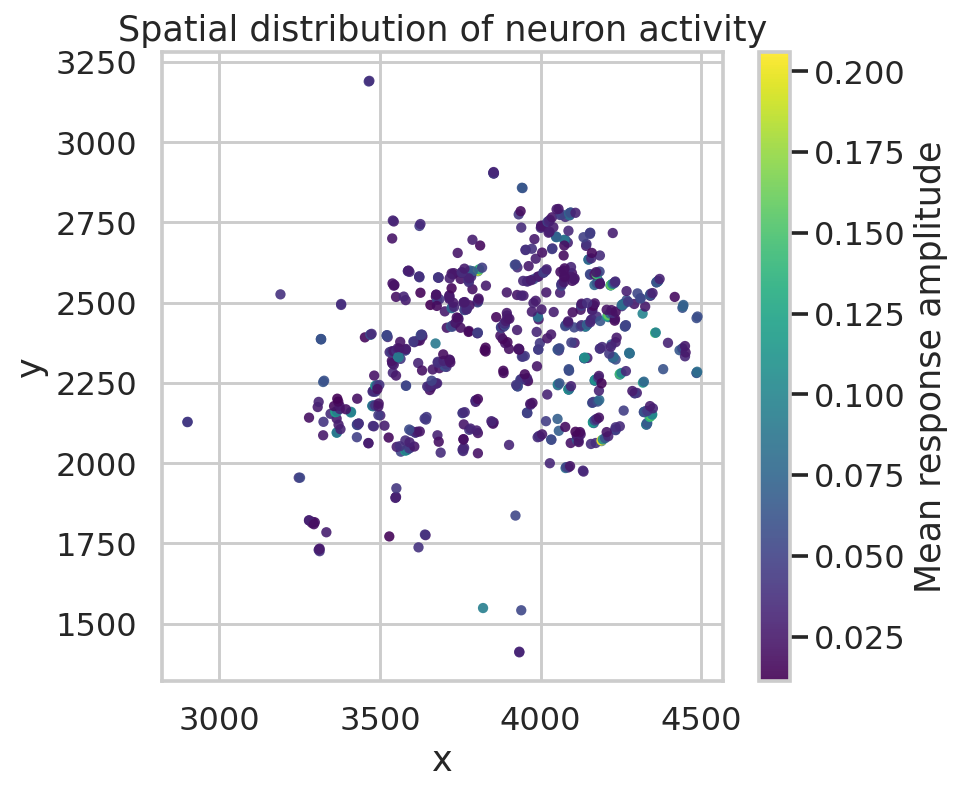

In [16]:
# -----------------------------
# Plot 1: spatial map of mean activity (across all trials)
# -----------------------------
activity_all = compute_activity_vector(segments)

fig, ax = plt.subplots(figsize=(7, 6), dpi=140)
sc = ax.scatter(
    neuron_pos_rr[1, :],
    neuron_pos_rr[0, :],
    c=activity_all,
    s=28,
    cmap="viridis",
    alpha=0.9,
    edgecolors="none",
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mean response amplitude")
ax.set_title("Spatial distribution of neuron activity")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(save_dir / "spatial_activity_map.png", dpi=220)
plt.show()


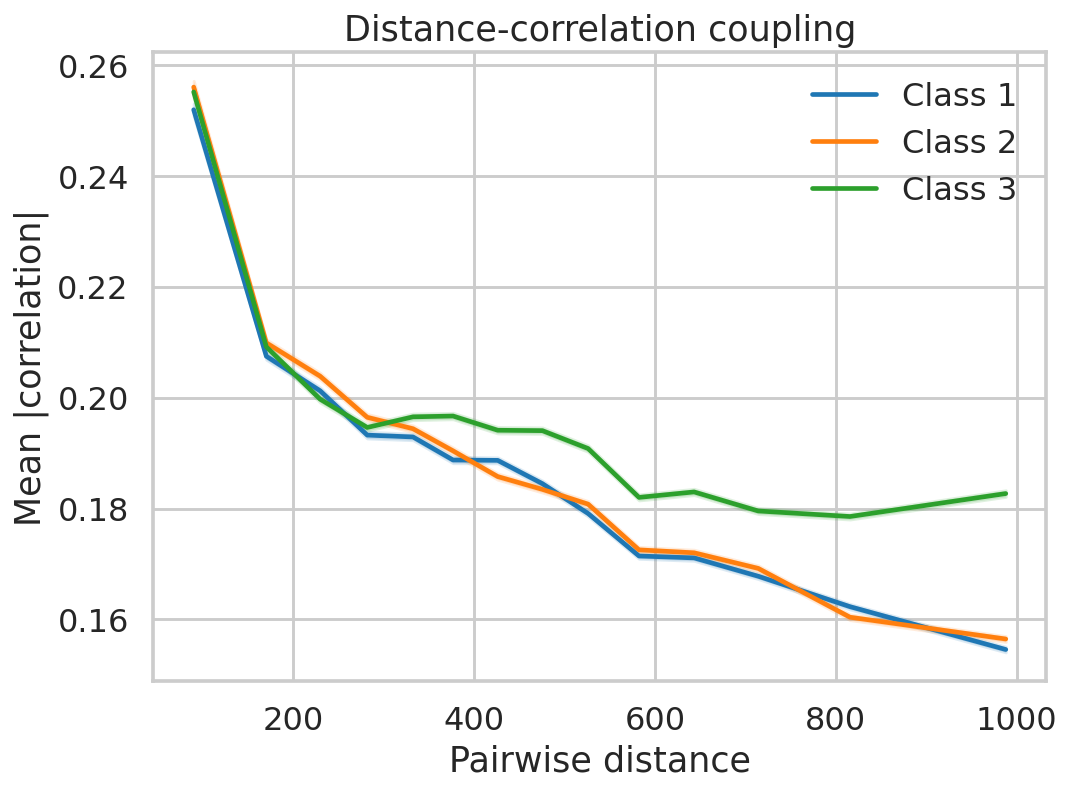

In [17]:
# -----------------------------
# Plot 2: abs(correlation) vs distance (class-wise)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
palette = sns.color_palette("tab10", n_colors=len(class_ids))

for color, cls in zip(palette, class_ids):
    dfc = pairs_all[pairs_all["class_id"] == cls].copy()
    summary = add_distance_bin_summary(dfc, value_col="abs_corr", n_bins=14)

    ax.plot(summary["distance_mid"], summary["value_mean"], color=color, lw=2.4, label=f"Class {cls}")
    ax.fill_between(
        summary["distance_mid"],
        summary["value_mean"] - summary["value_sem"],
        summary["value_mean"] + summary["value_sem"],
        color=color,
        alpha=0.15,
    )

ax.set_title("Distance-correlation coupling")
ax.set_xlabel("Pairwise distance")
ax.set_ylabel("Mean |correlation|")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_dir / "distance_vs_abs_correlation.png", dpi=220)
plt.show()


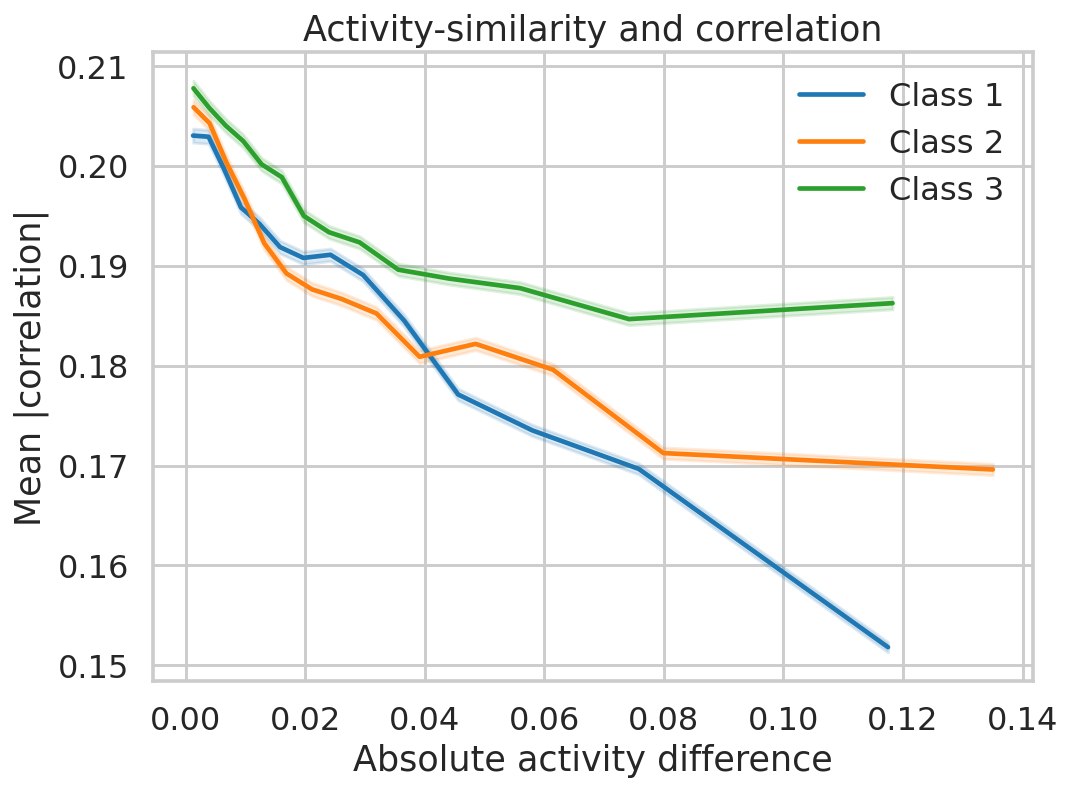

In [18]:
# -----------------------------
# Plot 3: abs(correlation) vs activity difference
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
for color, cls in zip(palette, class_ids):
    dfc = pairs_all[pairs_all["class_id"] == cls].copy()
    dfc["act_bin"] = pd.qcut(dfc["activity_diff"], q=14, duplicates="drop")
    s = dfc.groupby("act_bin", observed=False).agg(
        act_mid=("activity_diff", "median"),
        abs_corr_mean=("abs_corr", "mean"),
        abs_corr_sem=("abs_corr", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    ).reset_index(drop=True)

    ax.plot(s["act_mid"], s["abs_corr_mean"], color=color, lw=2.4, label=f"Class {cls}")
    ax.fill_between(
        s["act_mid"],
        s["abs_corr_mean"] - s["abs_corr_sem"],
        s["abs_corr_mean"] + s["abs_corr_sem"],
        color=color,
        alpha=0.15,
    )

ax.set_title("Activity-similarity and correlation")
ax.set_xlabel("Absolute activity difference")
ax.set_ylabel("Mean |correlation|")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_dir / "activity_diff_vs_abs_correlation.png", dpi=220)
plt.show()


In [19]:
# -----------------------------
# Optional: quick near-vs-far comparison
# -----------------------------
rows = []
for cls in class_ids:
    dfc = pairs_all[pairs_all["class_id"] == cls].copy()
    q1 = dfc["distance"].quantile(0.25)
    q3 = dfc["distance"].quantile(0.75)

    near_vals = dfc.loc[dfc["distance"] <= q1, "abs_corr"]
    far_vals = dfc.loc[dfc["distance"] >= q3, "abs_corr"]
    t_stat, p_val = stats.ttest_ind(near_vals, far_vals, equal_var=False)

    rows.append({
        "class_id": cls,
        "near_mean_abs_corr": near_vals.mean(),
        "far_mean_abs_corr": far_vals.mean(),
        "delta_near_minus_far": near_vals.mean() - far_vals.mean(),
        "welch_t": t_stat,
        "p_value": p_val,
        "near_n": len(near_vals),
        "far_n": len(far_vals),
    })

near_far_df = pd.DataFrame(rows)
near_far_df


,class_id,near_mean_abs_corr,far_mean_abs_corr,delta_near_minus_far,welch_t,p_value,near_n,far_n
0,1,0.216801,0.163000,0.053802,105.537452,0.0,65795,65794
1,2,0.219768,0.163409,0.056360,108.250533,0.0,65795,65794
2,3,0.218004,0.180412,0.037591,71.284551,0.0,65795,65794


In [20]:
# -----------------------------
# Save outputs
# -----------------------------
pairs_all.to_csv(save_dir / "pairwise_metrics.csv", index=False)
association_df.to_csv(save_dir / "association_summary.csv", index=False)
near_far_df.to_csv(save_dir / "near_far_summary.csv", index=False)

print("Saved to:", save_dir.resolve())
print("- pairwise_metrics.csv")
print("- association_summary.csv")
print("- near_far_summary.csv")
print("- spatial_activity_map.png")
print("- distance_vs_abs_correlation.png")
print("- activity_diff_vs_abs_correlation.png")


Saved to: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/brainnetwork/results/custom_correlation_activity_space
- pairwise_metrics.csv
- association_summary.csv
- near_far_summary.csv
- spatial_activity_map.png
- distance_vs_abs_correlation.png
- activity_diff_vs_abs_correlation.png
